In [43]:
import numpy as np
import numpy as np
import torch
import sys, os
sys.path.append(os.path.abspath(".."))  # project root
print(os.path.abspath(".."))
from datasets.data import SpatialDataset
from datasets.transformerRegressorDataClass import TransformerPointDataset, collate_point_batches
from torch.utils.data import DataLoader
#from datasets.dt2_data import load_dt2_data
from models.transformerRegressor import TransformerCLSRegressor
import numpy as np
import matplotlib.pyplot as plt
from argument_transformer import parse_opt

c:\Users\ORITMI\OneDrive - Rafael\Project B - Alon Asaf Orit\kcn-torch-master\Project-B-Technion


In [41]:
# Show the current working directory
from pathlib import Path
print(os.getcwd())
os.chdir("..")
sys.path.append(os.path.abspath(".."))  # project root
print(os.path.abspath(".."))
p_cache = Path("cache")
print("cache exists?", p_cache.exists(), "->", p_cache.resolve())
trainset = torch.load(r"./cache/trainset_2_M_points_10_nei_new_saving_with_batching.pt",map_location="cpu",weights_only=False)
validset = torch.load(r"./cache/validset_2_M_points_10_nei_new_saving_with_batching.pt",map_location="cpu",weights_only=False)
testset = torch.load(r"./cache/testset_2_M_points_10_nei_new_saving_with_batching.pt",map_location="cpu",weights_only=False)

c:\Users\ORITMI\OneDrive - Rafael\Project B - Alon Asaf Orit\kcn-torch-master\Project-B-Technion\kcn-torch-master\Transformer_Map_Interp
c:\Users\ORITMI\OneDrive - Rafael\Project B - Alon Asaf Orit\kcn-torch-master\Project-B-Technion
cache exists? True -> C:\Users\ORITMI\OneDrive - Rafael\Project B - Alon Asaf Orit\kcn-torch-master\Project-B-Technion\kcn-torch-master\cache


FileNotFoundError: [Errno 2] No such file or directory: './cache/trainset_2_M_points_10_nei_new_saving_with_batching.pt'

In [13]:
avg_size = sum(len(inner > 0) for inner in validset.obs_coords_norm) / len(validset.obs_coords_norm)
print(f"Number of neighbors at Val set: {avg_size}")
print(f"size of validset: {len(validset.obs_coords_norm)}")
print(avg_size)

avg_size = sum(len(inner > 0) for inner in testset.obs_coords_norm) / len(testset.obs_coords_norm)
print(f"Number of neighbors at Test set: {avg_size}")
print(f"size of testset: {len(testset.obs_coords_norm)}")

avg_size = sum(len(inner) for inner in trainset.obs_coords_norm) / len(trainset.obs_coords_norm)
print(f"Number of neighbors at Train set:{avg_size}")
print(f"size of trainset: {len(trainset.obs_coords_norm)}")

print(trainset.y_std.detach().cpu().numpy())
print(trainset.y_mean.detach().cpu().numpy())

print("trainset obs coords norm:", trainset.obs_coords_norm.shape)
#print("trainset obs coords norm:", trainset.obs_coords_norm[1])

print("trainset obs coords:", trainset.obs_coords.shape)
print("trainset obs coords norm:", trainset.obs_coords[1])

Number of neighbors at Val set: 10.0
size of validset: 81022
10.0
Number of neighbors at Test set: 10.0
size of testset: 81022
Number of neighbors at Train set:10.0
size of trainset: 2431575
300.9501
274.30548
trainset obs coords norm: torch.Size([2431575, 10, 2])
trainset obs coords: torch.Size([2431575, 10, 2])
trainset obs coords norm: tensor([[32.5773, 35.4538],
        [32.5726, 35.4588],
        [32.5720, 35.4585],
        [32.5751, 35.4521],
        [32.5776, 35.4585],
        [32.5759, 35.4618],
        [32.5732, 35.4604],
        [32.5693, 35.4504],
        [32.5757, 35.4496],
        [32.5754, 35.4535]])


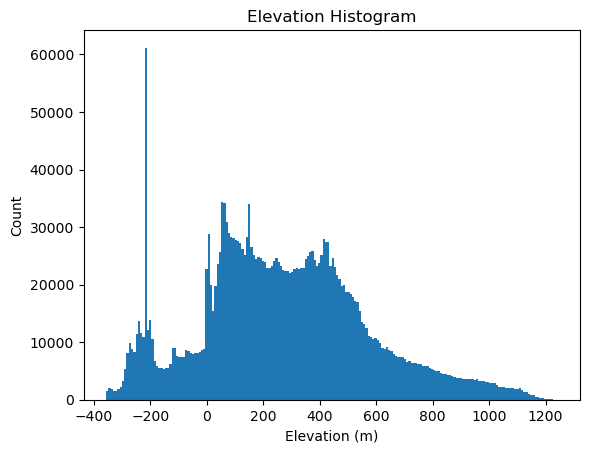

Min: -357.0
Max: 1241.0
Std: 300.94998
Mean: 274.30554


In [5]:
vals = trainset.y.numpy().reshape(-1)

plt.hist(vals, bins=200)
plt.title("Elevation Histogram")
plt.xlabel("Elevation (m)")
plt.ylabel("Count")
plt.show()

print("Min:", vals.min())
print("Max:", vals.max())
print("Std:", vals.std())
print("Mean:", vals.mean())

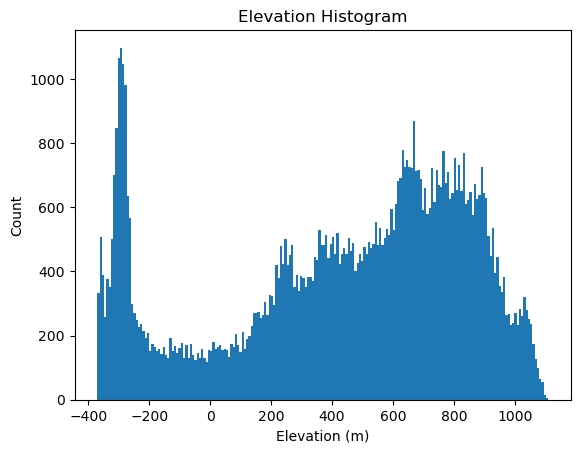

Min: -371.0
Max: 1110.0
Std: 408.5057
Mean: 433.53357


In [6]:
vals = validset.y.numpy().reshape(-1)

plt.hist(vals, bins=200)
plt.title("Elevation Histogram")
plt.xlabel("Elevation (m)")
plt.ylabel("Count")
plt.show()

print("Min:", vals.min())
print("Max:", vals.max())
print("Std:", vals.std())
print("Mean:", vals.mean())

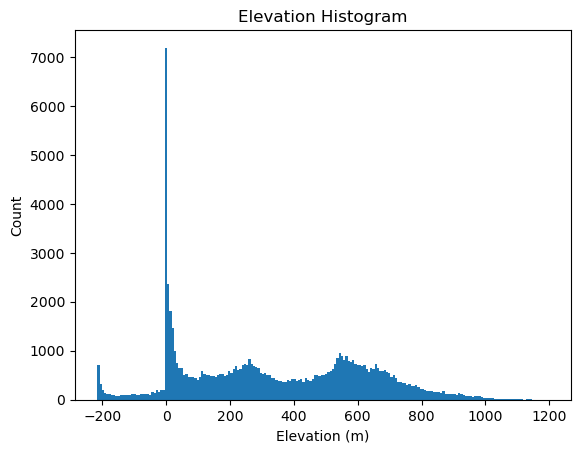

Min: -216.0
Max: 1197.0
Std: 287.47955
Mean: 334.72598


In [7]:
vals = testset.y.numpy().reshape(-1)

plt.hist(vals, bins=200)
plt.title("Elevation Histogram")
plt.xlabel("Elevation (m)")
plt.ylabel("Count")
plt.show()

print("Min:", vals.min())
print("Max:", vals.max())
print("Std:", vals.std())
print("Mean:", vals.mean())

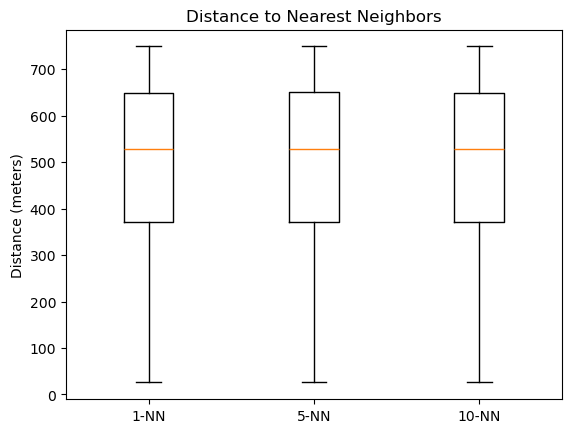

Mean distances: 500.12625 500.05045 499.99637


In [10]:
coords = trainset.coords.numpy()
obs_coords = trainset.obs_coords.numpy()
obs_coords_norm = trainset.obs_coords_norm.numpy()   # shape (N, max_obs, 2)


# Compute conversion constants (same as in your KDTree builder)
lat0 = trainset.coords[:,0].mean().item()
k_lat = 110.574
k_lon = 111.320 * np.cos(np.deg2rad(lat0))

# Compute distances in meters for each neighbor
dlat = obs_coords_norm[...,0]   # (N, max_obs)
dlon = obs_coords_norm[...,1]   # (N, max_obs)

# Convert degrees → meters
dx = dlon * k_lon * 1000
dy = dlat * k_lat * 1000
dists = np.sqrt(dx**2 + dy**2)   # final distance matrix (N, max_obs)

# dist[ :, 1:] removes the self-distance = 0 
#d = dists[:, 1:]

plt.boxplot(dists[:, [0,4,9]])   # 1st, 5th, 10th nearest
plt.xticks([1,2,3], ["1-NN", "5-NN", "10-NN"])
plt.ylabel("Distance (meters)")
plt.title("Distance to Nearest Neighbors")
plt.show()

print("Mean distances:", dists[:,0].mean(), dists[:,4].mean(), dists[:,9].mean())


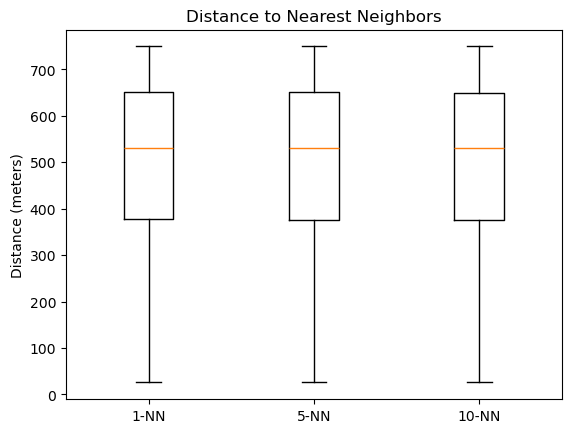

Mean distances: 501.9327 501.06696 501.017


In [11]:
coords = validset.coords.numpy()
obs_coords = validset.obs_coords.numpy()
obs_coords_norm = validset.obs_coords_norm.numpy()   # shape (N, max_obs, 2)


# Compute conversion constants (same as in your KDTree builder)
lat0 = trainset.coords[:,0].mean().item()
k_lat = 110.574
k_lon = 111.320 * np.cos(np.deg2rad(lat0))

# Compute distances in meters for each neighbor
dlat = obs_coords_norm[...,0]   # (N, max_obs)
dlon = obs_coords_norm[...,1]   # (N, max_obs)

# Convert degrees → meters
dx = dlon * k_lon * 1000
dy = dlat * k_lat * 1000
dists = np.sqrt(dx**2 + dy**2)   # final distance matrix (N, max_obs)

# dist[ :, 1:] removes the self-distance = 0 
#d = dists[:, 1:]

plt.boxplot(dists[:, [0,4,9]])   # 1st, 5th, 10th nearest
plt.xticks([1,2,3], ["1-NN", "5-NN", "10-NN"])
plt.ylabel("Distance (meters)")
plt.title("Distance to Nearest Neighbors")
plt.show()

print("Mean distances:", dists[:,0].mean(), dists[:,4].mean(), dists[:,9].mean())

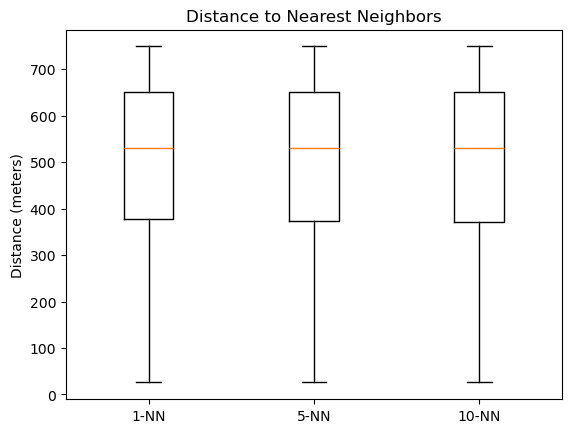

Mean distances: 501.99304 501.23187 500.26382


In [12]:
coords = testset.coords.numpy()
obs_coords = testset.obs_coords.numpy()
obs_coords_norm = testset.obs_coords_norm.numpy()   # shape (N, max_obs, 2)


# Compute conversion constants (same as in your KDTree builder)
lat0 = trainset.coords[:,0].mean().item()
k_lat = 110.574
k_lon = 111.320 * np.cos(np.deg2rad(lat0))

# Compute distances in meters for each neighbor
dlat = obs_coords_norm[...,0]   # (N, max_obs)
dlon = obs_coords_norm[...,1]   # (N, max_obs)

# Convert degrees → meters
dx = dlon * k_lon * 1000
dy = dlat * k_lat * 1000
dists = np.sqrt(dx**2 + dy**2)   # final distance matrix (N, max_obs)

# dist[ :, 1:] removes the self-distance = 0 
#d = dists[:, 1:]

plt.boxplot(dists[:, [0,4,9]])   # 1st, 5th, 10th nearest
plt.xticks([1,2,3], ["1-NN", "5-NN", "10-NN"])
plt.ylabel("Distance (meters)")
plt.title("Distance to Nearest Neighbors")
plt.show()

print("Mean distances:", dists[:,0].mean(), dists[:,4].mean(), dists[:,9].mean())

In [6]:

def meters_per_degree(latitude_deg):
    lat_m = 111_320.0  # meters per 1 degree latitude (good enough for your scale)
    lon_m = 111_320.0 * np.cos(np.radians(latitude_deg))
    return lat_m, lon_m


In [46]:
# Load the DTED file
import rasterio
print(os.getcwd())
#os.chdir("..")
#dt2_file = "./datasets/merged.tif" 
dt2_file = "Transformer_Map_Interp/datasets/n32_e035_1arc_v3.dt2"
with rasterio.open(dt2_file) as dataset:
    #nodata = dataset.nodata
    bounds = dataset.bounds
    width, height = dataset.width, dataset.height
    xres_deg, yres_deg = dataset.res  # deg/pixel (yres will likely be negative)
    xres_deg = float(xres_deg)
    yres_deg = abs(float(yres_deg))
     # FIX: read the elevation correctly
    elevation = dataset.read(1).astype(float)

    #elevation = np.ma.masked_equal(elevation, nodata)

    # Mid-latitude for better lon->meters conversion
    mid_lat = (bounds.top + bounds.bottom) / 2.0

    # meters per degree at this latitude
    lat_m_per_deg, lon_m_per_deg = meters_per_degree(mid_lat)

    # meters per pixel
    xres_m = lon_m_per_deg * xres_deg
    yres_m = lat_m_per_deg * yres_deg
    transform = dataset.transform # affine transform for pixel->geo coords
    # total map size in meters
    width_m  = xres_m * width
    height_m = yres_m * height

    # Also keep extent for plotting
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

c:\Users\ORITMI\OneDrive - Rafael\Project B - Alon Asaf Orit\kcn-torch-master\Project-B-Technion\kcn-torch-master


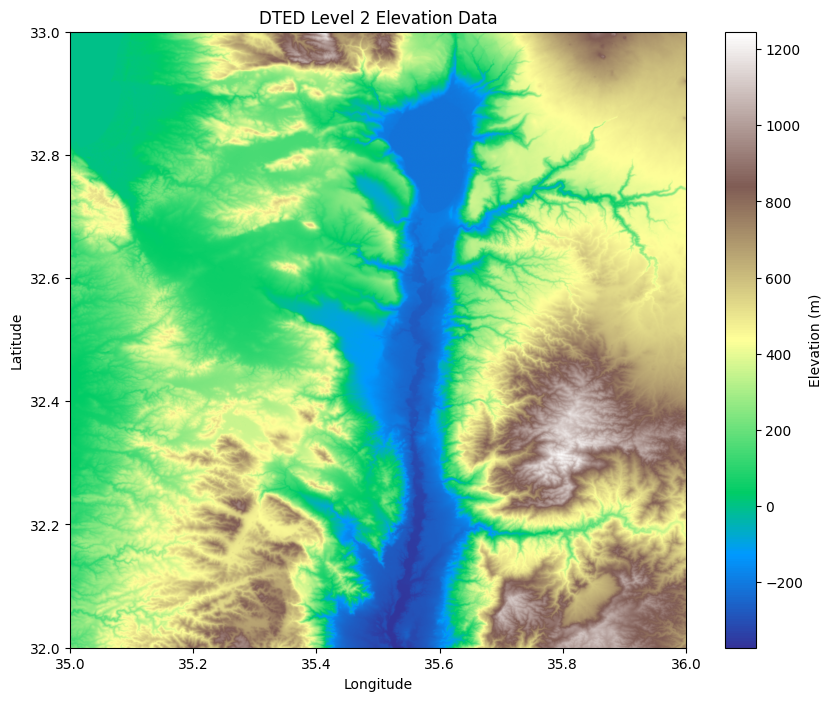

Number of points: (3601, 3601) 


In [47]:
plt.figure(figsize=(10, 8))
plt.imshow(elevation, cmap="terrain", extent=extent, origin="upper")
#plt.scatter(xs, ys, c=vals, s=2, cmap="terrain", marker='.')
plt.colorbar(label="Elevation (m)")
plt.title("DTED Level 2 Elevation Data")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
#plt.savefig("Transformer_Map_Interp/datasets/full_dt2_region.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Number of points: {elevation.shape} ")

In [ ]:
elevation_zero = (elevation != 0) 
plt.figure(figsize=(10, 8))
plt.scatter(elevation_zero, cmap="terrain", extent=extent, origin="upper")
#plt.scatter(xs, ys, c=vals, s=2, cmap="terrain", marker='.')
plt.colorbar(label="Elevation (m)")
plt.title("DTED Level 2 Elevation Data")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
#plt.savefig("Transformer_Map_Interp/datasets/full_dt2_region.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Number of points: {elevation_zero.shape} ")

TypeError: scatter() missing 1 required positional argument: 'y'

<Figure size 1000x800 with 0 Axes>

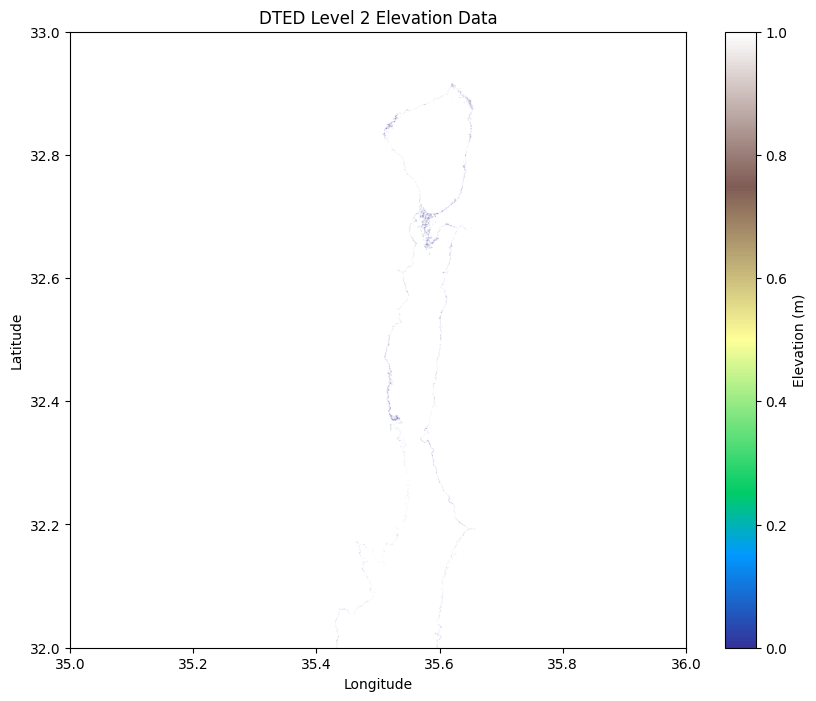

Number of points: (3601, 3601) 


In [51]:
elevation_zero = (elevation != -200) 
plt.figure(figsize=(10, 8))
plt.imshow(elevation_zero, cmap="terrain", extent=extent, origin="upper")
#plt.scatter(xs, ys, c=vals, s=2, cmap="terrain", marker='.')
plt.colorbar(label="Elevation (m)")
plt.title("DTED Level 2 Elevation Data")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
#plt.savefig("Transformer_Map_Interp/datasets/full_dt2_region.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Number of points: {elevation_zero.shape} ")

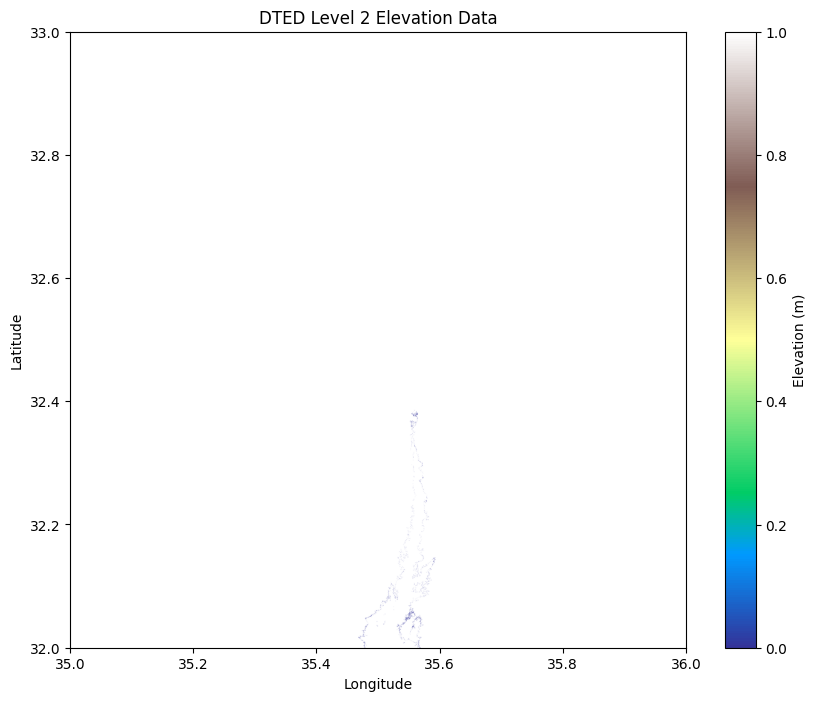

Number of points: (3601, 3601) 


In [52]:
elevation_zero = (elevation != -300) 
plt.figure(figsize=(10, 8))
plt.imshow(elevation_zero, cmap="terrain", extent=extent, origin="upper")
#plt.scatter(xs, ys, c=vals, s=2, cmap="terrain", marker='.')
plt.colorbar(label="Elevation (m)")
plt.title("DTED Level 2 Elevation Data")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
#plt.savefig("Transformer_Map_Interp/datasets/full_dt2_region.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Number of points: {elevation_zero.shape} ")

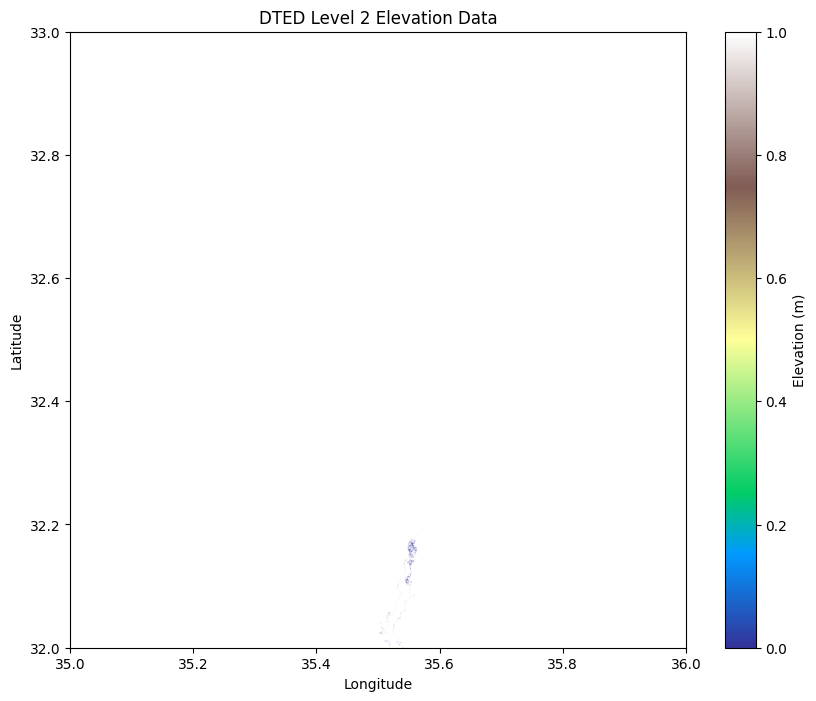

Number of points: (3601, 3601) 


In [54]:
elevation_zero = (elevation != -350) 
plt.figure(figsize=(10, 8))
plt.imshow(elevation_zero, cmap="terrain", extent=extent, origin="upper")
#plt.scatter(xs, ys, c=vals, s=2, cmap="terrain", marker='.')
plt.colorbar(label="Elevation (m)")
plt.title("DTED Level 2 Elevation Data")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
#plt.savefig("Transformer_Map_Interp/datasets/full_dt2_region.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Number of points: {elevation_zero.shape} ")

(12967201,)


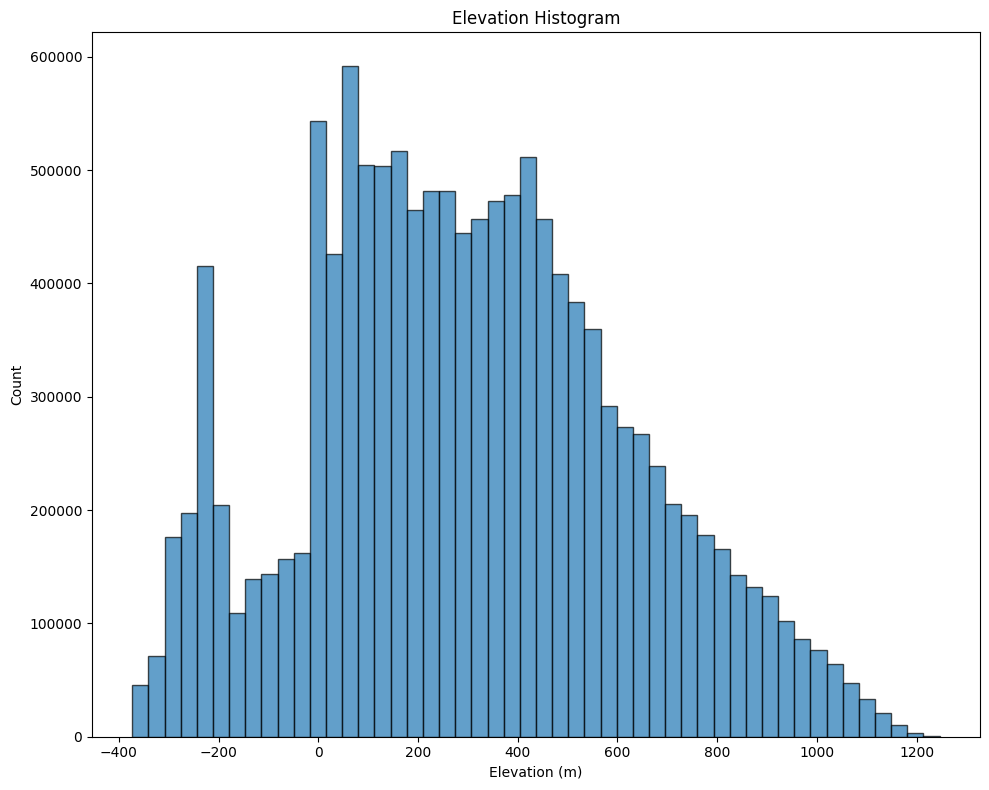

In [27]:
plt.figure(figsize=(10, 8))
#plt.hist(elevation, bins=50)  # adjust bins as you like
elev_vec = elevation.flatten()
print(elev_vec.shape)
plt.hist(elevation.flatten(), bins=50, alpha=0.7, edgecolor='black')

plt.xlabel("Elevation (m)")
plt.ylabel("Count")
plt.title("Elevation Histogram")
plt.tight_layout()
#plt.savefig("Transformer_Map_Interp/datasets/full_dt2_elevation_hist.png", dpi=200)
plt.show()

In [28]:
# Load the DTED file
import rasterio
print(os.getcwd())
#os.chdir("..")
dt2_file = "./datasets/n32_e035_1arc_v3_cropped_train.tiff" 
#dt2_file = "Transformer_Map_Interp/datasets/n33_e035_1arc_v3.dt2"
with rasterio.open(dt2_file) as dataset:
    #nodata = dataset.nodata
    bounds = dataset.bounds
    width, height = dataset.width, dataset.height
    xres_deg, yres_deg = dataset.res  # deg/pixel (yres will likely be negative)
    xres_deg = float(xres_deg)
    yres_deg = abs(float(yres_deg))
     # FIX: read the elevation correctly
    elevation = dataset.read(1).astype(float)

    #elevation = np.ma.masked_equal(elevation, nodata)

    # Mid-latitude for better lon->meters conversion
    mid_lat = (bounds.top + bounds.bottom) / 2.0

    # meters per degree at this latitude
    lat_m_per_deg, lon_m_per_deg = meters_per_degree(mid_lat)

    # meters per pixel
    xres_m = lon_m_per_deg * xres_deg
    yres_m = lat_m_per_deg * yres_deg
    transform = dataset.transform # affine transform for pixel->geo coords
    # total map size in meters
    width_m  = xres_m * width
    height_m = yres_m * height

    # Also keep extent for plotting
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

c:\Users\ORITMI\OneDrive - Rafael\Project B - Alon Asaf Orit\kcn-torch-master\Project-B-Technion\kcn-torch-master\Transformer_Map_Interp


(9726301,)


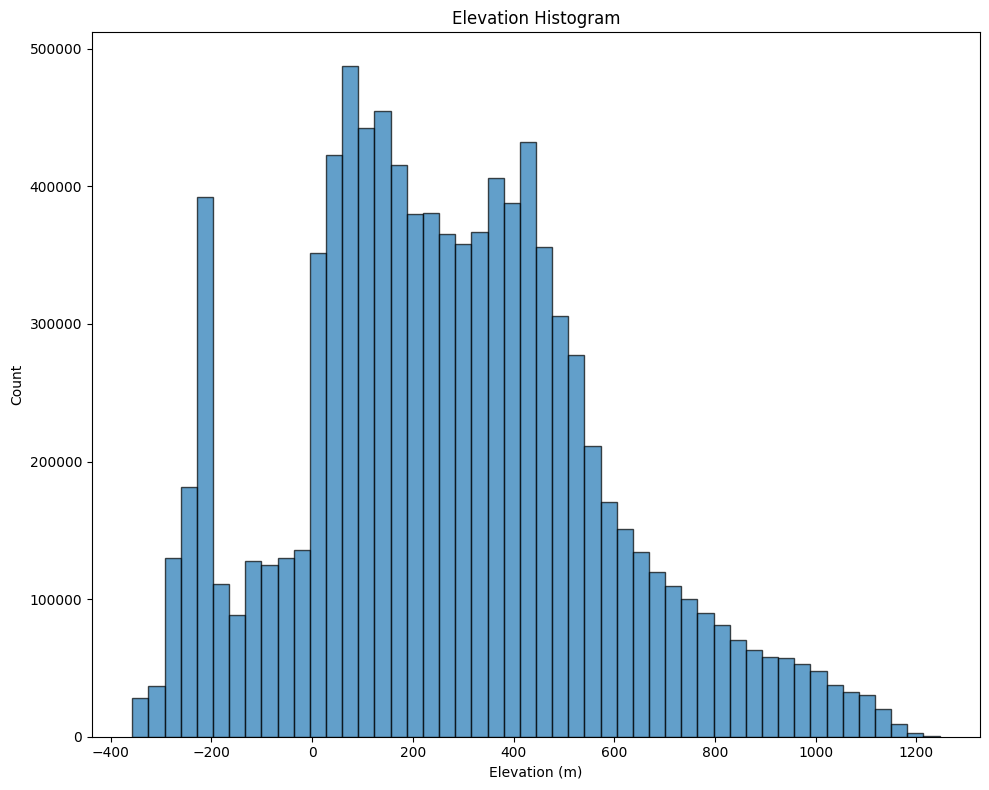

In [29]:
plt.figure(figsize=(10, 8))
#plt.hist(elevation, bins=50)  # adjust bins as you like
elev_vec = elevation.flatten()
print(elev_vec.shape)
plt.hist(elevation.flatten(), bins=50, alpha=0.7, edgecolor='black')

plt.xlabel("Elevation (m)")
plt.ylabel("Count")
plt.title("Elevation Histogram")
plt.tight_layout()
#plt.savefig("Transformer_Map_Interp/datasets/full_dt2_elevation_hist.png", dpi=200)
plt.show()

In [30]:
# Load the DTED file
import rasterio
print(os.getcwd())
#os.chdir("..")
dt2_file = "./datasets/n32_e035_1arc_v3_cropped_val.tiff" 
#dt2_file = "Transformer_Map_Interp/datasets/n33_e035_1arc_v3.dt2"
with rasterio.open(dt2_file) as dataset:
    #nodata = dataset.nodata
    bounds = dataset.bounds
    width, height = dataset.width, dataset.height
    xres_deg, yres_deg = dataset.res  # deg/pixel (yres will likely be negative)
    xres_deg = float(xres_deg)
    yres_deg = abs(float(yres_deg))
     # FIX: read the elevation correctly
    elevation = dataset.read(1).astype(float)

    #elevation = np.ma.masked_equal(elevation, nodata)

    # Mid-latitude for better lon->meters conversion
    mid_lat = (bounds.top + bounds.bottom) / 2.0

    # meters per degree at this latitude
    lat_m_per_deg, lon_m_per_deg = meters_per_degree(mid_lat)

    # meters per pixel
    xres_m = lon_m_per_deg * xres_deg
    yres_m = lat_m_per_deg * yres_deg
    transform = dataset.transform # affine transform for pixel->geo coords
    # total map size in meters
    width_m  = xres_m * width
    height_m = yres_m * height

    # Also keep extent for plotting
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

c:\Users\ORITMI\OneDrive - Rafael\Project B - Alon Asaf Orit\kcn-torch-master\Project-B-Technion\kcn-torch-master\Transformer_Map_Interp


(1620450,)


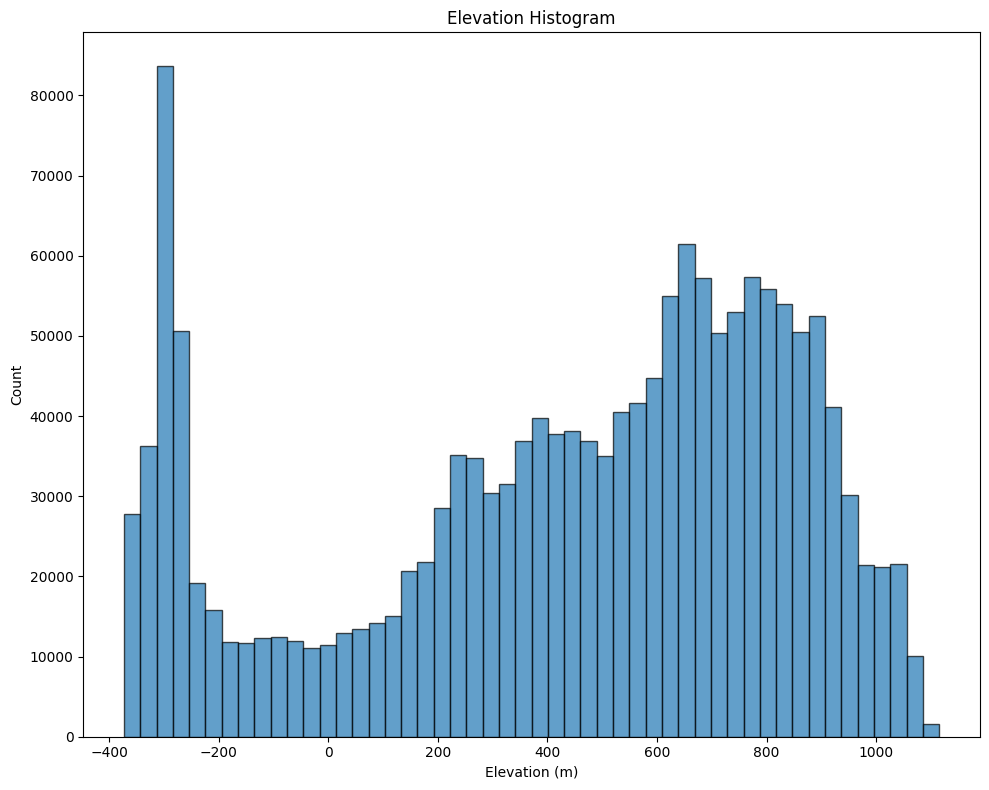

In [31]:
plt.figure(figsize=(10, 8))
#plt.hist(elevation, bins=50)  # adjust bins as you like
elev_vec = elevation.flatten()
print(elev_vec.shape)
plt.hist(elevation.flatten(), bins=50, alpha=0.7, edgecolor='black')

plt.xlabel("Elevation (m)")
plt.ylabel("Count")
plt.title("Elevation Histogram")
plt.tight_layout()
#plt.savefig("Transformer_Map_Interp/datasets/full_dt2_elevation_hist.png", dpi=200)
plt.show()

In [42]:
# Load the DTED file
import rasterio
print(os.getcwd())
#os.chdir("..")
dt2_file = "./datasets/n32_e035_1arc_v3_cropped_test.tiff" 
#dt2_file = "Transformer_Map_Interp/datasets/n33_e035_1arc_v3.dt2"
with rasterio.open(dt2_file) as dataset:
    #nodata = dataset.nodata
    bounds = dataset.bounds
    width, height = dataset.width, dataset.height
    xres_deg, yres_deg = dataset.res  # deg/pixel (yres will likely be negative)
    xres_deg = float(xres_deg)
    yres_deg = abs(float(yres_deg))
     # FIX: read the elevation correctly
    elevation = dataset.read(1).astype(float)

    #elevation = np.ma.masked_equal(elevation, nodata)

    # Mid-latitude for better lon->meters conversion
    mid_lat = (bounds.top + bounds.bottom) / 2.0

    # meters per degree at this latitude
    lat_m_per_deg, lon_m_per_deg = meters_per_degree(mid_lat)

    # meters per pixel
    xres_m = lon_m_per_deg * xres_deg
    yres_m = lat_m_per_deg * yres_deg
    transform = dataset.transform # affine transform for pixel->geo coords
    # total map size in meters
    width_m  = xres_m * width
    height_m = yres_m * height

    # Also keep extent for plotting
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

c:\Users\ORITMI\OneDrive - Rafael\Project B - Alon Asaf Orit\kcn-torch-master\Project-B-Technion\kcn-torch-master


RasterioIOError: ./datasets/n32_e035_1arc_v3_cropped_test.tiff: No such file or directory

(1620450,)


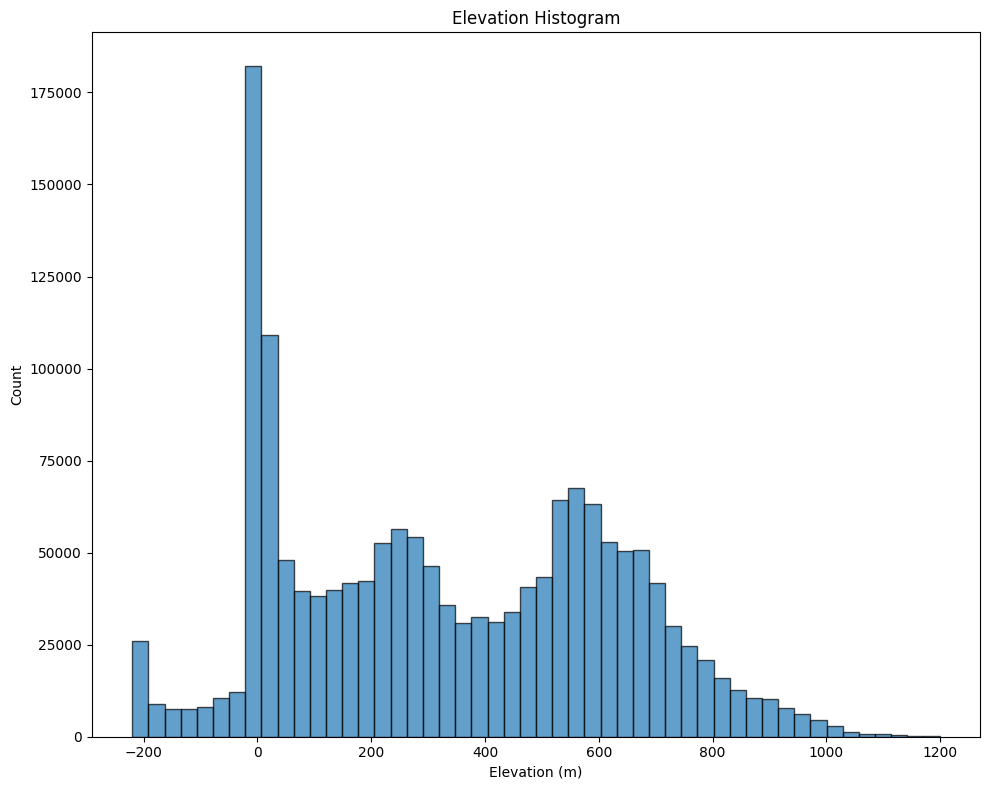

In [33]:
plt.figure(figsize=(10, 8))
#plt.hist(elevation, bins=50)  # adjust bins as you like
elev_vec = elevation.flatten()
print(elev_vec.shape)
plt.hist(elevation.flatten(), bins=50, alpha=0.7, edgecolor='black')

plt.xlabel("Elevation (m)")
plt.ylabel("Count")
plt.title("Elevation Histogram")
plt.tight_layout()
#plt.savefig("Transformer_Map_Interp/datasets/full_dt2_elevation_hist.png", dpi=200)
plt.show()